<a href="https://colab.research.google.com/github/sadhub10/SIC-2025-Aulas-Pa09-y-Pa10/blob/main/Clase%202%20-%20Practica%20-%20IA%20-%20Capitulo%208%20-%20Unidad%202%20-%2024/11/2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Códigos Comunes en la Unidad 2.2: Carga de Datos con TensorFlow (tf.data.Datasets)

## Celda 1: Importar la librería tensorflow_datasetsy cargar un conjunto de datos (MNIST)
Este es el enfoque más probable para la sección "Carga de conjuntos de datos de la bibliotecatensorflow_datasets ".

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf

# Cargar el conjunto de datos MNIST
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # Para obtener tuplas (imagen, etiqueta)
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.QF6VS1_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.QF6VS1_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


## Celda 2: Función de normalización y mapeo
Generalmente, las imágenes deben normalizarse (escalar a un rango de 0 a 1) después de cargarlas.

In [ ]:
# Función para normalizar los datos (escalar las imágenes a [0, 1])
def normalize_img(image, label):
    """Normaliza las imágenes: `uint8` -> `float32`."""
    return tf.cast(image, tf.float32) / 255., label

# Aplicar la función de normalización al conjunto de entrenamiento
ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)

## Celda 3: Configurar el conjunto de datos para el entrenamiento
Para optimizar el rendimiento de la GPU/TPU, se suelen aplicar operaciones de almacenamiento en caché, mezcla aleatoria y creación de lotes.

In [ ]:
# Configurar los conjuntos de datos para rendimiento
BATCH_SIZE = 32

ds_train = ds_train.cache() # Almacena en caché los datos
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples) # Mezcla los datos
ds_train = ds_train.batch(BATCH_SIZE) # Crea lotes
ds_train = ds_train.prefetch(tf.data.AUTOTUNE) # Optimiza la precarga

# Aplicar operaciones al conjunto de prueba
ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

## Celda 4: Otro enfoque: Cargar datos directamente desde archivos (CSV o NumPy)
Este enfoque corresponde a la sección "Otro enfoque para cargar conjuntos de datos" y es fundamental cuando los datos no están disponibles entensorflow_datasets .

In [ ]:
import numpy as np
import pandas as pd

# Suponiendo que 'X_data.csv' y 'y_labels.csv' existen
# Cargar datos de ejemplo (Normalmente se usan archivos CSV o NumPy)
X_data = np.random.rand(100, 5) # 100 muestras, 5 características
y_labels = np.random.randint(0, 2, 100) # Etiquetas binarias

# Crear un Dataset a partir de NumPy
dataset = tf.data.Dataset.from_tensor_slices((X_data, y_labels))

# Aplicar shuffling y batching
dataset = dataset.shuffle(buffer_size=100).batch(32)

# Iterar y ver un lote (opcional)
for x, y in dataset.take(1):
    print("Forma del lote de características:", x.shape)
    print("Forma del lote de etiquetas:", y.shape)

Forma del lote de características: (32, 5)
Forma del lote de etiquetas: (32,)


## **MODELO KERAS**

### Celda 5: 🧠 Definición del Modelo Keras (CNN)
En esta celda, se define la arquitectura de la Red Neuronal Convolucional.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# El dataset MNIST contiene imágenes de 28x28 píxeles en escala de grises.
# La entrada debe ser (28, 28, 1)

# Definir el modelo secuencial
model = Sequential([
    # Capa Convolucional 1: 32 filtros, kernel 3x3, función ReLU
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Capa de Max Pooling (reduce el tamaño de la imagen)
    MaxPooling2D((2, 2)),

    # Capa Convolucional 2: 64 filtros, kernel 3x3
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Aplanar: convierte el mapa de características 2D en un vector 1D
    Flatten(),

    # Capa Densa (Fully Connected)
    Dense(128, activation='relu'),

    # Capa de Salida: 10 neuronas (una por cada dígito 0-9) con activación softmax
    Dense(10, activation='softmax')
])

print("Modelo CNN definido y listo para compilar.")

Modelo CNN definido y listo para compilar.


### Celda 5: ⚙️ Compilación del Modelo
Aquí configuramos cómo se aprenderá (optimizador), qué medir (función de pérdida) y cómo evaluar el rendimiento (métricas).

In [ ]:
# Definir la función de pérdida y el optimizador
model.compile(
    optimizer='adam', # Optimizador popular y eficiente
    # Función de pérdida para clasificación multiclase (10 dígitos)
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'] # Métrica principal para medir aciertos
)

# Imprimir el resumen del modelo para verificar la arquitectura
print("--- Resumen del Modelo ---")
model.summary()

--- Resumen del Modelo ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Celda 6: 🚀 Entrenamiento del Modelo
Entrenamos el modelo usando los conjuntos de datos que preparamos en las celdas 1-3.

In [ ]:
# Parámetros del entrenamiento
NUM_EPOCHS = 5 # El número de pasadas completas sobre el conjunto de entrenamiento

# Obtener el número de pasos por época (necesario para el modelo si usamos .repeat())
# MNIST tiene 60,000 imágenes de entrenamiento
STEPS_PER_EPOCH = ds_info.splits['train'].num_examples // BATCH_SIZE

print(f"Comenzando el entrenamiento por {NUM_EPOCHS} épocas...")

# Entrenar el modelo
history = model.fit(
    ds_train,
    epochs=NUM_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=ds_test # Usamos el conjunto de prueba para la validación
)

Comenzando el entrenamiento por 5 épocas...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9077 - loss: 0.3020 - val_accuracy: 0.9869 - val_loss: 0.0417
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9872 - loss: 0.0415 - val_accuracy: 0.9888 - val_loss: 0.0335
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9910 - loss: 0.0276 - val_accuracy: 0.9912 - val_loss: 0.0262
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9935 - loss: 0.0196 - val_accuracy: 0.9915 - val_loss: 0.0275
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9961 - loss: 0.0139 - val_accuracy: 0.9908 - val_loss: 0.0294


Una Época (Epoch) en Deep Learning es un concepto central del proceso de entrenamiento y se define de forma muy simple:

Una época es una pasada completa de la totalidad del conjunto de datos de entrenamiento a través del algoritmo de la red neuronal.

### 🔁 ¿Qué Sucede en una Época?
Una época representa un ciclo de aprendizaje completo, donde la red tiene la oportunidad de ver y aprender de cada ejemplo de entrenamiento. Durante este ciclo, la red realiza cuatro pasos clave:

* Propagación Adelante (Forward Pass): La red toma los datos de entrada y calcula una predicción de salida.

* Cálculo del Error (Loss): Se mide qué tan lejos está la predicción de la red del valor real (la verdad fundamental).

* Retropropagación (Backpropagation): El error se propaga hacia atrás a través de todas las capas, calculando el impacto (el gradiente) que cada peso tuvo en ese error.

* Ajuste de Pesos: El optimizador (como Adam o SGD) utiliza esos gradientes para modificar los pesos y sesgos de la red, minimizando el error para la siguiente pasada.

### 📈 La Importancia de las Múltiples Épocas
Generalmente, una red neuronal necesita múltiples épocas (a menudo cientos o miles) para que los pesos se ajusten lo suficiente y el modelo aprenda los patrones complejos en los datos.

* Pocas Épocas (Underfitting): Si el número de épocas es muy bajo, el modelo no habrá aprendido lo suficiente de los datos y tendrá un rendimiento deficiente.

* Demasiadas Épocas (Overfitting): Si se entrena por demasiadas épocas, el modelo empieza a "memorizar" el ruido y las particularidades del conjunto de entrenamiento en lugar de generalizar. Esto resulta en un rendimiento deficiente cuando se le presentan datos nuevos (no vistos).

En frameworks como TensorFlow/Keras, el número de épocas se controla con el parámetro epochs en la función de entrenamiento model.fit().

### Celda 7: ✅ Evaluación y Salida Final
Una vez entrenado, evaluamos el rendimiento final del modelo en el conjunto de prueba y mostramos las métricas de salida.

In [ ]:
# Evaluar el modelo en el conjunto de prueba (ds_test)
loss, accuracy = model.evaluate(ds_test, verbose=0)

print("--- Evaluación Final del Modelo ---")
print(f"Pérdida (Loss) en el conjunto de prueba: {loss:.4f}")
print(f"Precisión (Accuracy) en el conjunto de prueba: {accuracy:.4f}")

--- Evaluación Final del Modelo ---
Pérdida (Loss) en el conjunto de prueba: 0.0294
Precisión (Accuracy) en el conjunto de prueba: 0.9908


## Métodos

Los métodos .shuffle(), .batch(), y .repeat()son las operaciones fundamentales y casi siempre obligatorias en la tubería de procesamiento de datos de TensorFlow ( tf.data.Dataset) que se ve en la Unidad 2.2 y se aplica en unidades posteriores.

La secuencia ideal para optimizar el rendimiento y la calidad del entrenamiento es la siguiente:

### 1. Explicación de los Métodos

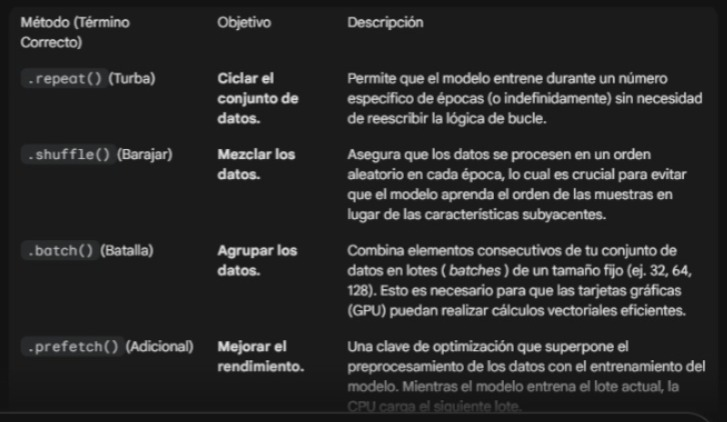

### 1. 🐍 Creación de la base de datos
Primero, creamos el conjunto de datos inicial:

In [ ]:
import tensorflow as tf

# Crear un Dataset a partir de una lista simple (números del 0 al 9)
data = list(range(10))
dataset = tf.data.Dataset.from_tensor_slices(data)

# Imprimir el dataset original (los 10 elementos)
print("--- Dataset Original ---")
for element in dataset.as_numpy_iterator():
    print(element, end=" ")
print("\n" + "-"*30)

--- Dataset Original ---
0 1 2 3 4 5 6 7 8 9 
------------------------------


### 2. 🔀 Ejemplo de .shuffle()(Mezclar)
El método .shuffle()toma un buffer_size, que es la cantidad de elementos de los que se extraerá la muestra aleatoria. Un buffer más grande ofrece una mejor mezcla.

In [ ]:
# Aplicar SHUFFLE con un buffer_size de 5
shuffled_dataset = dataset.shuffle(buffer_size=5)

print("--- Después de .shuffle(5) ---")
# Solo tomamos 5 elementos para demostrar que el orden cambia
for element in shuffled_dataset.take(5).as_numpy_iterator():
    print(element, end=" ")
print("\n" + "-"*30)

# NOTA: Los elementos impresos serán aleatorios (ej. 4 8 0 6 2)

--- Después de .shuffle(5) ---
4 3 2 0 1 
------------------------------


### 3. 📦 Ejemplo de .batch()(Agrupar en Lotes)
El método.batch() agrupa los elementos en tensores del tamaño especificado.

In [ ]:
# Aplicar BATCH con un tamaño de lote (batch_size) de 3
batched_dataset = dataset.batch(batch_size=3)

print("--- Después de .batch(3) ---")
# Imprimimos los lotes. El último lote puede ser más pequeño.
for batch in batched_dataset.as_numpy_iterator():
    print(batch, end=" ")
print("\n" + "-"*30)

# Resultado esperado: [0 1 2] [3 4 5] [6 7 8] [9]

--- Después de .batch(3) ---
[0 1 2] [3 4 5] [6 7 8] [9] 
------------------------------


### 4. 🔁 Ejemplo de .repeat()(Repetir)
El método .repeat()repite el conjunto de datos el número de veces que se indica. Si se usa None(como en el ejemplo, o se deja vacío), se repite infinitamente.

In [ ]:
# Aplicar REPEAT 2 veces
repeated_dataset = dataset.repeat(count=2)

print("--- Después de .repeat(2) ---")
# Imprimimos los primeros 15 elementos (de los 20 totales)
for element in repeated_dataset.take(12).as_numpy_iterator():
    print(element, end=" ")
print("\n" + "-"*30)

# Resultado esperado: 0 1 2 3 4 5 6 7 8 9 (primera repetición) 0 1 2 3 4 (segunda repetición parcial)

--- Después de .repeat(2) ---
0 1 2 3 4 5 6 7 8 9 0 1 
------------------------------
